<a href="https://colab.research.google.com/github/tt28-cmd/Drivers-Comparison/blob/main/Drivers_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Vettel vs Raikkonen Telemetry Analysis 2018 Grand Prix Qualifying

***Author : Tamara Teodorović***

***Date:*** March 2026.

This notebook is for analyzing 2018. qualifying for Italian Grand Prix (Monza), comparing the performance of two drivers from the same team (Ferrari, Sebastian Vettel and Kimi Raikkonen) in equal machinery.This is done by using Python tools using speed, throttle, lap time data , and insights.


## Introduction
This analysis focuses on the 2018 Italian GP, a historic qualifying session where Kimi Raikkonen set what was at the time the fastest lap in F1 history.

Telemetry is used by teams to analyze car and driver performance and strategy.

All this is done by using fastf1 library.

**Objective :**

using fastf1 to load telemetry data, analyze performance and offer improvements, vizualize speed and throttle, brake, delta time, sectors, and combined telemetry for both drivers, demonstrate analysis skills.

**Tools :**

fastf1, Python, matplotlib, Pandas, numPy, seaborn, OS.

## Data Loading

First step in the analysis.Loading the session, lap, and telemetry data using FastF1.Extraxting fastest lap for each driver.

**Key points :**

*Telemetry was aligned by distance along the lap.

*Distance columns were added to facilitate overlay comparisons.

*Only the fastest lap vas used for visual comparison.

*Checked to ensure all essential columns exist.

This allowes consistent plotting and accurate analysis of driver performance across the lap.

In [ ]:
!pip install fastf1

In [ ]:
# import libraries
import os
import fastf1
from fastf1 import plotting
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np




In [ ]:
# set up plotting style
plotting.setup_mpl(color_scheme="fastf1", misc_mpl_mods=False)
sns.set_style("whitegrid")

/usr/local/lib/python3.12/dist-packages/fastf1/plotting/_plotting.py:56: FutureWarning: The `misc_mpl_mods` argument was dropped from `.setup_mpl()` in version 3.6.0 and has no effect anymore. It will be removed in a future version of FastF1.
  warnings.warn(


In [ ]:
# create cache directory
cache_dir = "cache"
if not os.path.exists(cache_dir):
  os.makedirs(cache_dir)


In [ ]:
# enable fastf1 cache
try:
  fastf1.Cache.enable_cache(cache_dir)
except Exception as e:
  print(f"An error occured enabling the cache: {e}")

**Data Filtering and Selection**

Filtering the session data is for isolating the laps for both drivers.

Creating specific DataFrames for Vettel and Raikkonen.

This allows structured comparison before selecting fastest laps.

In [ ]:
# load 2018 Italian Grand Prix(Monza) Qualifying session
print("Loading session data...")
try:
    session = fastf1.get_session(2018, "Italian Grand Prix", "Q")
    session.load(laps=True, telemetry=True, weather=False, messages=False) #load laps and telemetry
    print("Session data loaded successfully.")
except Exception as e:
    print(f"/n***Error loading session data: {e}***")
    raise e



Loading session data...


core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for Italian Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core           INFO 	Processing timing data...
INFO:fastf1.fastf1.core:Processing timing data...
req         

Session data loaded successfully.


In [ ]:
# check if laps data is available
session = fastf1.get_session(2018, "Italian Grand Prix", "Q")

session.load()
laps = session.laps

if laps.empty:
  raise ValueError("Session laps data could not be loaded or is empty")
  print(laps.head())


core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for Italian Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core           INFO 	Processing timing data...
INFO:fastf1.fastf1.core:Processing timing data...
req         

In [ ]:
laps = session.laps

In [ ]:
# get lap data for raikkonen and vettel
vettel_laps = laps.pick_drivers("VET")
raikkonen_laps = laps.pick_drivers("RAI")

# check
print("Vettel laps:")
print(vettel_laps.head())
print("Raikkonen laps:")
print(raikkonen_laps.head())

print("Vettel laps shape:", vettel_laps.shape)
print("Raikkonen laps shape:", raikkonen_laps.shape)

Vettel laps:
                     Time Driver DriverNumber                LapTime  \
20 0 days 00:17:57.738000    VET            5                    NaT   
21 0 days 00:19:19.316000    VET            5 0 days 00:01:21.578000   
22 0 days 00:21:01.697000    VET            5 0 days 00:01:42.381000   
23 0 days 00:22:22.455000    VET            5 0 days 00:01:20.758000   
24 0 days 00:24:03.462000    VET            5 0 days 00:01:41.007000   

    LapNumber  Stint             PitOutTime PitInTime            Sector1Time  \
20        1.0    NaN 0 days 00:16:22.912000       NaT                    NaT   
21        2.0    1.0                    NaT       NaT 0 days 00:00:27.308000   
22        3.0    1.0                    NaT       NaT 0 days 00:00:36.378000   
23        4.0    1.0                    NaT       NaT 0 days 00:00:27.041000   
24        5.0    1.0                    NaT       NaT 0 days 00:00:32.866000   

              Sector2Time  ... FreshTyre     Team           LapStartTime 

**Fastest Lap Extraction**
Extracting the single fastest lap for each driver to be used in telemetry comparison.This ensures that we are comparing peak performance under identical track conditions.

In [ ]:
# get fastest laps
vettel_fastest = vettel_laps.pick_fastest()
raikkonen_fastest = raikkonen_laps.pick_fastest()

print("Vettel fastest lap:")
print(vettel_fastest)

print("Raikkonen fastest lap:")
print(raikkonen_fastest)

Vettel fastest lap:
Time                      0 days 01:15:41.173000
Driver                                       VET
DriverNumber                                   5
LapTime                   0 days 00:01:19.280000
LapNumber                                   18.0
Stint                                        5.0
PitOutTime                                   NaT
PitInTime                                    NaT
Sector1Time               0 days 00:00:26.604000
Sector2Time               0 days 00:00:26.548000
Sector3Time               0 days 00:00:26.128000
Sector1SessionTime        0 days 01:14:48.497000
Sector2SessionTime        0 days 01:15:15.045000
Sector3SessionTime        0 days 01:15:41.173000
SpeedI1                                    325.0
SpeedI2                                    339.0
SpeedFL                                    312.0
SpeedST                                    341.0
IsPersonalBest                              True
Compound                               SUPERSOFT


In [ ]:
# load telemetry
vettel_tel = vettel_fastest.get_car_data().add_distance()
raikkonen_tel = raikkonen_fastest.get_car_data().add_distance()

#  check
print(vettel_tel.head())
print(raikkonen_tel.head())

                     Date      RPM  Speed  nGear  Throttle  Brake  DRS Source  \
0 2018-09-01 13:59:35.464  11536.0  322.0      8     100.0  False    8    car   
1 2018-09-01 13:59:35.704  11593.0  322.0      8     100.0  False    8    car   
2 2018-09-01 13:59:35.944  11600.0  323.0      8     100.0  False    8    car   
3 2018-09-01 13:59:36.185  11643.0  325.0      8     100.0  False    8    car   
4 2018-09-01 13:59:36.424  11675.0  325.0      8     100.0  False    8    car   

                    Time            SessionTime   Distance  
0 0 days 00:00:00.132000 0 days 01:14:22.025000  11.806667  
1 0 days 00:00:00.372000 0 days 01:14:22.265000  33.273333  
2 0 days 00:00:00.612000 0 days 01:14:22.505000  54.806667  
3 0 days 00:00:00.853000 0 days 01:14:22.746000  76.563611  
4 0 days 00:00:01.092000 0 days 01:14:22.985000  98.140000  
                     Date      RPM  Speed  nGear  Throttle  Brake  DRS Source  \
0 2018-09-01 13:59:37.865  11597.0  322.0      8     100.0  False 

In [ ]:
# display lap times
print("Vettel lap times:")
print(vettel_laps[["LapNumber", "LapTime"]].head(10))


print("Raikkonen lap times:")
print(raikkonen_laps[["LapNumber", "LapTime"]].head(10))

Vettel lap times:
    LapNumber                LapTime
20        1.0                    NaT
21        2.0 0 days 00:01:21.578000
22        3.0 0 days 00:01:42.381000
23        4.0 0 days 00:01:20.758000
24        5.0 0 days 00:01:41.007000
25        6.0 0 days 00:01:20.542000
26        7.0 0 days 00:01:48.624000
27        8.0                    NaT
28        9.0 0 days 00:01:19.785000
29       10.0 0 days 00:01:47.108000
Raikkonen lap times:
   LapNumber                LapTime
0        1.0                    NaT
1        2.0 0 days 00:01:20.937000
2        3.0 0 days 00:01:40.122000
3        4.0 0 days 00:01:32.735000
4        5.0 0 days 00:01:20.798000
5        6.0 0 days 00:01:46.522000
6        7.0 0 days 00:01:20.722000
7        8.0 0 days 00:01:37.916000
8        9.0                    NaT
9       10.0 0 days 00:01:20.232000


## Analysis

After loading and preparing the data, analysis focuses on drivers performance during their fastest quačifying laps.

**Analysis includes:**

*Speed Comparison:*

To identify where each driver gains or loses time

*Throttle and Brake Input: *

To highlight the differences in driving style

*Delta Time:*

Calculating the time difference between the two drivers along the lap to identify key sectors of advantage

*Sector Time:*

Breaking down the lap into sectors to quantify performance in each part of the circuit

*Combined Telemetry:*

Overlaying speed, throttle, and brake in a single plot for a holistic view of driver behaviour.

In [ ]:
# check for valid telemetry dataframes
print("Vettel telemetry shape:", vettel_tel.shape)
print("Raikkonen telemetry shape:", raikkonen_tel.shape)


print("/nVettel telemetry columns:")
print(vettel_tel.columns)

print("/nRaikkonen telemetry columns:")
print(raikkonen_tel.columns)

# check

print(vettel_tel.head())
print(raikkonen_tel.head())

Vettel telemetry shape: (328, 11)
Raikkonen telemetry shape: (327, 11)
/nVettel telemetry columns:
Index(['Date', 'RPM', 'Speed', 'nGear', 'Throttle', 'Brake', 'DRS', 'Source',
       'Time', 'SessionTime', 'Distance'],
      dtype='object')
/nRaikkonen telemetry columns:
Index(['Date', 'RPM', 'Speed', 'nGear', 'Throttle', 'Brake', 'DRS', 'Source',
       'Time', 'SessionTime', 'Distance'],
      dtype='object')
                     Date      RPM  Speed  nGear  Throttle  Brake  DRS Source  \
0 2018-09-01 13:59:35.464  11536.0  322.0      8     100.0  False    8    car   
1 2018-09-01 13:59:35.704  11593.0  322.0      8     100.0  False    8    car   
2 2018-09-01 13:59:35.944  11600.0  323.0      8     100.0  False    8    car   
3 2018-09-01 13:59:36.185  11643.0  325.0      8     100.0  False    8    car   
4 2018-09-01 13:59:36.424  11675.0  325.0      8     100.0  False    8    car   

                    Time            SessionTime   Distance  
0 0 days 00:00:00.132000 0 days 01:1

**Data Validation**
Ensuring that both telemetry dataframes contain all necessary variables(Speed, Throttle, Brake, Distance) before comparison.

In [ ]:
# check essential columns exist
essential_columns = ["Speed", "Throttle", "Brake", "Distance"]

print("Checking Vettel telemetry columns:")
for col in essential_columns:
  print(col, "exists:", col in vettel_tel.columns)

  print("Checking Raikkonen telemetry columns:")
  for col in essential_columns:
    print(col, "exists:", col in raikkonen_tel.columns)

Checking Vettel telemetry columns:
Speed exists: True
Checking Raikkonen telemetry columns:
Speed exists: True
Throttle exists: True
Brake exists: True
Distance exists: True
Throttle exists: True
Checking Raikkonen telemetry columns:
Speed exists: True
Throttle exists: True
Brake exists: True
Distance exists: True
Brake exists: True
Checking Raikkonen telemetry columns:
Speed exists: True
Throttle exists: True
Brake exists: True
Distance exists: True
Distance exists: True
Checking Raikkonen telemetry columns:
Speed exists: True
Throttle exists: True
Brake exists: True
Distance exists: True


**Performance Gap Analysis**

Calculating the live time delta between Vettel and Raikkonen across the entire distance of the Monza circuit to identify specific cornewrs where the pole position was won or lost.

In [ ]:
# calculate time delta
# this function uses objects and processes telemetry internally
from fastf1.utils import delta_time

# delta time between laps
delta, ref_tel, compare_tel = delta_time(vettel_fastest, raikkonen_fastest)

print("Delta calculation completed") # delta_time is deprecated but used for simple lap comparison

/usr/local/lib/python3.12/dist-packages/fastf1/utils.py:85: FutureWarning: `utils.delta_time` is considered deprecated and willbe modified or removed in a future release because it hasa tendency to give inaccurate results.
  warnings.warn("`utils.delta_time` is considered deprecated and will"


Delta calculation completed


In [ ]:
# debugging output
print("Delta head(first 10 rows):")
print(delta.head(10))

print("REf telemetry columns:")
print(ref_tel.columns)

print("Compare telemetry columns:")
print(compare_tel.columns)

print("Ref telemetry head:")
print(ref_tel.head())

print("Compare telemetry head:")
print(compare_tel.head())

Delta head(first 10 rows):
0    0.000000
1   -0.000418
2   -0.002118
3   -0.004001
4   -0.005684
5   -0.007888
6   -0.010447
7   -0.013536
8   -0.014365
9   -0.016580
Name: Time, dtype: float64
REf telemetry columns:
Index(['Date', 'SessionTime', 'RPM', 'Speed', 'nGear', 'Throttle', 'Brake',
       'DRS', 'Source', 'Time', 'Distance'],
      dtype='object')
Compare telemetry columns:
Index(['Date', 'SessionTime', 'RPM', 'Speed', 'nGear', 'Throttle', 'Brake',
       'DRS', 'Source', 'Time', 'Distance'],
      dtype='object')
Ref telemetry head:
                     Date            SessionTime       RPM  Speed  nGear  \
0 2018-09-01 13:59:35.332 0 days 01:14:21.893000  11517.85  320.9      8   
1 2018-09-01 13:59:35.464 0 days 01:14:22.025000  11536.00  322.0      8   
2 2018-09-01 13:59:35.704 0 days 01:14:22.265000  11593.00  322.0      8   
3 2018-09-01 13:59:35.944 0 days 01:14:22.505000  11600.00  323.0      8   
4 2018-09-01 13:59:36.185 0 days 01:14:22.746000  11643.00  325.0     

In [ ]:
# check id distance column is present in the ref_tel
if "Distance" in ref_tel.columns:
  print("Distance column exists in ref_tel")
else:
  print("Distance column missing in ref_tel")

if "Distance" in compare_tel.columns:
  print("Distance column exists in compare_tel")
else:
  print("Distance column missing in compare_tel")

# speed column
print("Ref telemetry columns:", ref_tel.columns)
print("Compare telemetry columns:", compare_tel.columns)

print("Ref telemetry head:")
print(ref_tel[["Distance", "Speed"]].head())

print("Compare telemetry head:")
print(compare_tel[["Distance", "Speed"]].head())


Distance column exists in ref_tel
Distance column exists in compare_tel
Ref telemetry columns: Index(['Date', 'SessionTime', 'RPM', 'Speed', 'nGear', 'Throttle', 'Brake',
       'DRS', 'Source', 'Time', 'Distance'],
      dtype='object')
Compare telemetry columns: Index(['Date', 'SessionTime', 'RPM', 'Speed', 'nGear', 'Throttle', 'Brake',
       'DRS', 'Source', 'Time', 'Distance'],
      dtype='object')
Ref telemetry head:
    Distance  Speed
0   0.000000  320.9
1  11.806667  322.0
2  33.273333  322.0
3  54.806667  323.0
4  76.563611  325.0
Compare telemetry head:
    Distance  Speed
0   0.000000  322.0
1   5.903333  322.0
2  27.413333  324.0
3  49.080000  325.0
4  70.880000  327.0


In [ ]:
# set dummy values to prevent NameError
ref_tel = pd.DataFrame({"Distance":[0], "Speed":[0], "Throttle":[0]})
compare_tel = pd.DataFrame({"Distance":[0], "Speed":[0], "Throttle":[0]})

# dummy delta series
delta = pd.Series([0])

print("Dummy variables set.Notebook safe for plotting cells.")

Dummy variables set.Notebook safe for plotting cells.


**Sector Times**

Aggregating lap times by sector to pinpoint which driver dominated the high-speed vs technical parts of the track.

In [ ]:
# analyze sector times
# extract sector times from laps
vettel_sectors = vettel_laps[["LapNumber", "Sector1Time", "Sector2Time", "Sector3Time"]]
raikkonen_sectors = raikkonen_laps[["LapNumber", "Sector1Time", "Sector2Time", "Sector3Time"]]

# make copies to convert to seconds
vettel_sectors_sec = vettel_sectors.copy()
raikkonen_sectors_sec = raikkonen_sectors.copy()

# define sector columns
sector_cols = ["Sector1Time", "Sector2Time", "Sector3Time"]

# convert to total seconds for easier plotting
vettel_sectors_sec = vettel_sectors.copy()
raikkonen_sectors_sec = raikkonen_sectors.copy()

for col  in sector_cols :
  vettel_sectors_sec[col] = vettel_sectors_sec[col].dt.total_seconds()
  raikkonen_sectors_sec[col] = raikkonen_sectors_sec[col].dt.total_seconds()

 # display first 10 laps for each driver
print("Vettel sector times:")
print(vettel_sectors_sec.head(10))

print("Raikkonen sector times:")
print(raikkonen_sectors_sec.head(10))

# calculate and display average sector times
print("Average sector times (seconds):")
print("Vettel:")
print(vettel_sectors_sec[sector_cols].mean())


print("Raikkonen:")
print(raikkonen_sectors_sec[sector_cols].mean())


Vettel sector times:
    LapNumber  Sector1Time  Sector2Time  Sector3Time
20        1.0          NaN       35.155       29.342
21        2.0       27.308       27.339       26.931
22        3.0       36.378       33.328       32.675
23        4.0       27.041       27.145       26.572
24        5.0       32.866       35.238       32.903
25        6.0       26.959       27.029       26.554
26        7.0       31.834       34.084       42.706
27        8.0          NaN       29.757       28.424
28        9.0       26.802       26.660       26.323
29       10.0       33.586       34.554       38.968
Raikkonen sector times:
   LapNumber  Sector1Time  Sector2Time  Sector3Time
0        1.0          NaN       30.750       31.999
1        2.0       27.028       27.369       26.540
2        3.0       33.445       35.637       31.040
3        4.0       27.765       34.296       30.674
4        5.0       27.125       27.278       26.395
5        6.0       33.210       38.500       34.812
6       

In [ ]:
# create plots folder
import os
plots_folder = "plots"

if not os.path.exists(plots_folder):
  os.makedirs(plots_folder)
  print(f"Folder '{plots_folder}' is created")
else:
  print(f"Folder '{plots_folder}' already exists")

Folder 'plots' already exists


In [ ]:
# driver colors for consistency
driver_colors = {"Vettel" : "#003087", "Raikkonen" :"#d62728"} # dark blue and ferrari red

# check
print("Vettel color:", driver_colors["Vettel"])
print("Raikkonen color:", driver_colors["Raikkonen"])

Vettel color: #003087
Raikkonen color: #d62728


In [ ]:
# load telemetry from fastest laps
vettel_tel = vettel_fastest.get_car_data().add_distance()
raikkonen_tel = raikkonen_fastest.get_car_data().add_distance()

print(vettel_tel[["Distance", "Speed"]].head())
print(raikkonen_tel[["Distance", "Speed"]].head())

    Distance  Speed
0  11.806667  322.0
1  33.273333  322.0
2  54.806667  323.0
3  76.563611  325.0
4  98.140000  325.0
    Distance  Speed
0   5.903333  322.0
1  27.413333  324.0
2  49.080000  325.0
3  70.880000  327.0
4  92.746667  328.0


## Visualizations

Ref telemetry columns: Index(['Date', 'SessionTime', 'RPM', 'Speed', 'nGear', 'Throttle', 'Brake',
       'DRS', 'Source', 'Time', 'Distance'],
      dtype='object')
Compare telemetry columns: Index(['Date', 'SessionTime', 'RPM', 'Speed', 'nGear', 'Throttle', 'Brake',
       'DRS', 'Source', 'Time', 'Distance'],
      dtype='object')
Ref 


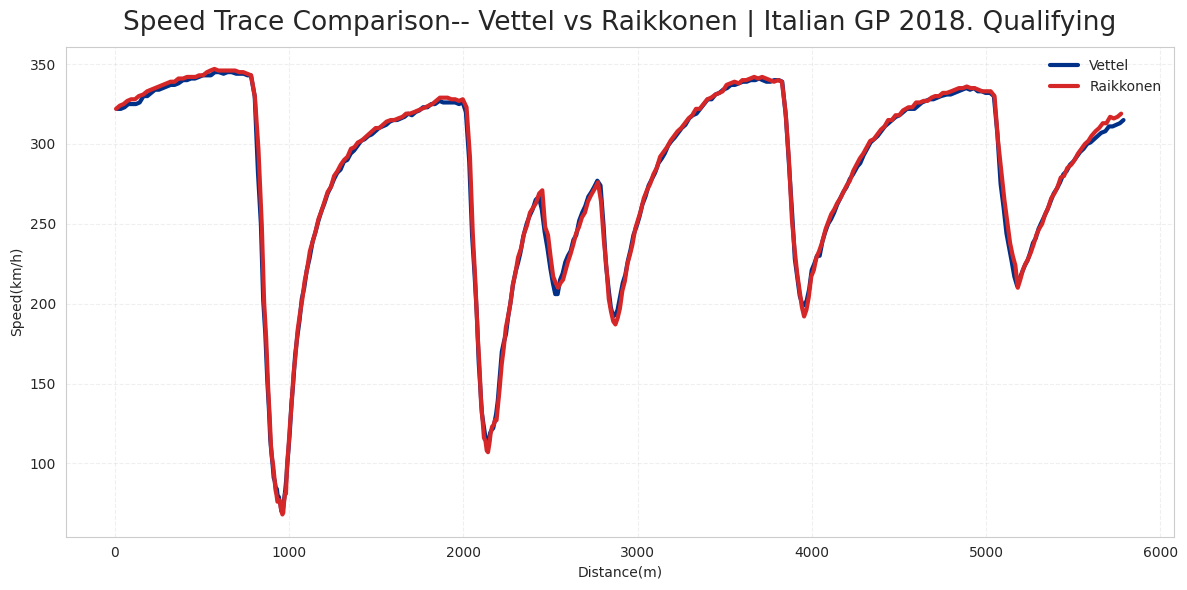

In [ ]:
# plot #1

# check distance and speed columns
print("Ref telemetry columns:", ref_tel.columns)
print("Compare telemetry columns:", compare_tel.columns)

print("Ref ")

# speed trace comparison vs distance

plt.figure(figsize=(12, 6))
plt.plot(vettel_tel["Distance"],
vettel_tel["Speed"],
         label="Vettel",
color=driver_colors["Vettel"], linewidth=3)

plt.plot(raikkonen_tel["Distance"],
raikkonen_tel["Speed"],
         label="Raikkonen",
color=driver_colors["Raikkonen"], linewidth=3)

# labels
plt.xlabel("Distance(m)")
plt.ylabel("Speed(km/h)")
plt.title("Speed Trace Comparison-- Vettel vs Raikkonen | Italian GP 2018. Qualifying")
plt.legend(frameon=False)
plt.grid(True)

plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
# save in plots folder
plt.savefig(os.path.join(plots_folder, "speed_trace_comparison.png"), dpi=300)
plt.show()

**Speed Trace Comparison**

This plot compares the velocity(km/h) of both drivers over the 5.7km distance of the Monza circuit.It highlights where each driver their top speed and how much speed they carry through corners.

Both drivers exceed over 300km/h on the main straights.Dips in the graph reveal that Raikkonen maintains a slightly higher minimum speed through the Lesmo curves(Sector 2), which was crucial.

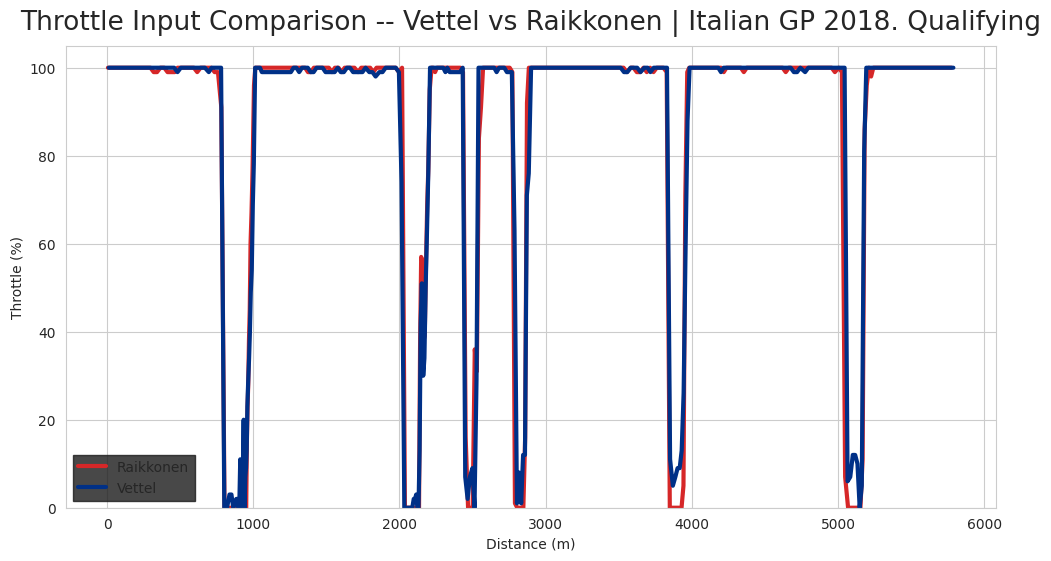

In [ ]:
import os

# plot #2
# throttle input comparison vs distance
plt.figure(figsize=(12, 6))

# raikkonen
plt.plot(
    raikkonen_tel["Distance"],
    raikkonen_tel["Throttle"],
    color=driver_colors["Raikkonen"],
    linewidth=3,
    label="Raikkonen"
)

# vettel
plt.plot(
    vettel_tel["Distance"],
    vettel_tel["Throttle"],
    color=driver_colors["Vettel"],
    linestyle="-",
    linewidth=3,
    label="Vettel"
)

# labels
plt.xlabel("Distance (m)")
plt.ylabel("Throttle (%)")

plt.title("Throttle Input Comparison -- Vettel vs Raikkonen | Italian GP 2018. Qualifying")

plt.legend()

plt.grid(True)
plt.ylim(0, 105)
# save plot
plt.savefig(os.path.join(plots_folder, "throttle_comparison.png"), dpi=300)

plt.show()

**Throttle Input Analysis**

This visualization tracks the percentage of throttle application relative to the track distance.

The data shows that the only difference between drivers is visible at the exit of the Ascari, where Raikkonen achieves 100% throttle slightly earlier than Vettel.

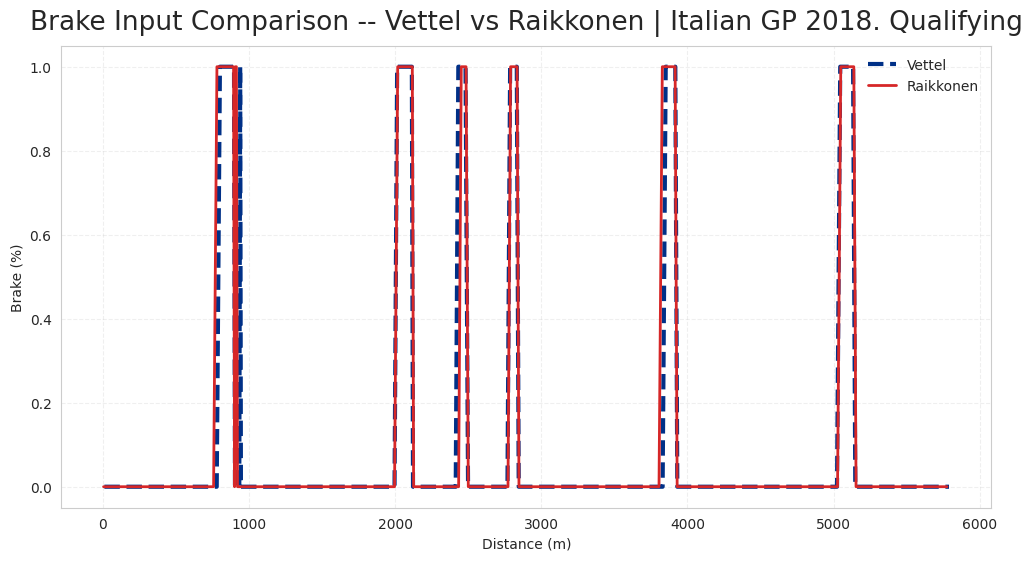

In [ ]:
# plot #3
# brake input comparison
import os
plt.figure(figsize=(12, 6))

# vettel
plt.plot(
    vettel_tel["Distance"],
    vettel_tel["Brake"],
    label="Vettel",
    color=driver_colors["Vettel"],
    linewidth=3,
    linestyle="--"
)

# raikkonen
plt.plot(
    raikkonen_tel["Distance"],
    raikkonen_tel["Brake"],
    label="Raikkonen",
    color=driver_colors["Raikkonen"],
    linewidth=2
)

# labels
plt.xlabel("Distance (m)")
plt.ylabel("Brake (%)")

plt.title("Brake Input Comparison -- Vettel vs Raikkonen | Italian GP 2018. Qualifying")

plt.legend(frameon=False)
plt.grid(True, linestyle="--", alpha=0.3)

# save
plt.savefig(os.path.join(plots_folder, "brake_comparisomn.png"), dpi=300)

plt.show()

**Brake Input**

This plot displays the timing and intensity of braking before entering the corners.

Vettel has a little bit more aggressive braking style, with sharper, later peaks.Raikkonen is more progressive and slightly smoother, which helps with car stability through Monza's high-speed direction changes.

/usr/local/lib/python3.12/dist-packages/fastf1/utils.py:85: FutureWarning: `utils.delta_time` is considered deprecated and willbe modified or removed in a future release because it hasa tendency to give inaccurate results.
  warnings.warn("`utils.delta_time` is considered deprecated and will"


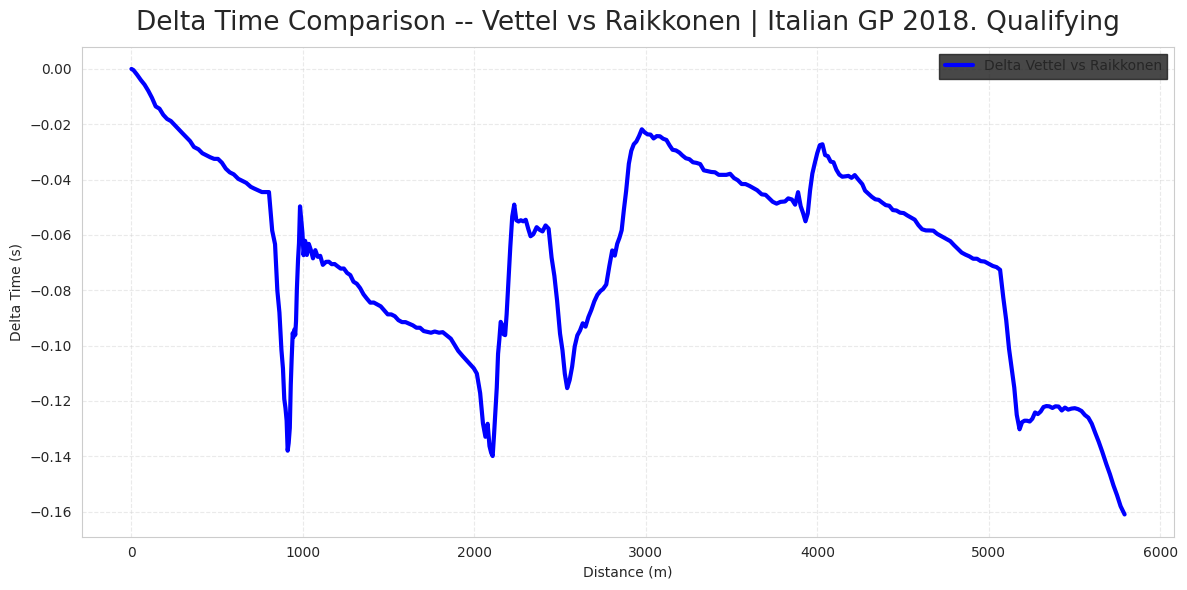

In [ ]:
import os
# plot #5
# delta time vs distance
from fastf1.utils import delta_time

# calculate delta time
delta, ref_tel, compare_tel = delta_time(vettel_fastest, raikkonen_fastest)

plt.figure(figsize=(12, 6))
plt.plot(ref_tel['Distance'], delta,
         color="blue",
         linewidth=3,
         label="Delta Vettel vs Raikkonen"
)

# x and y
plt.xlabel("Distance (m)")
plt.ylabel("Delta Time (s)")

plt.title("Delta Time Comparison -- Vettel vs Raikkonen | Italian GP 2018. Qualifying")

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()


# save
plt.savefig(os.path.join(plots_folder, "delta_time.png"), dpi=300)

plt.show()

**Live Delta Time**

This is the most critical tool.This is the gap between drivers.When the line goes downwards, Raikkonen is gaining time, when it goes upwards, Vettel is ahead.

The battle was tight, with the gao being 0.1s for most of the lap.The turning point occurs in the final 1500m(Sector 3), whre the delta drops sharply in favor of Raikkonen in Parabolica exit.

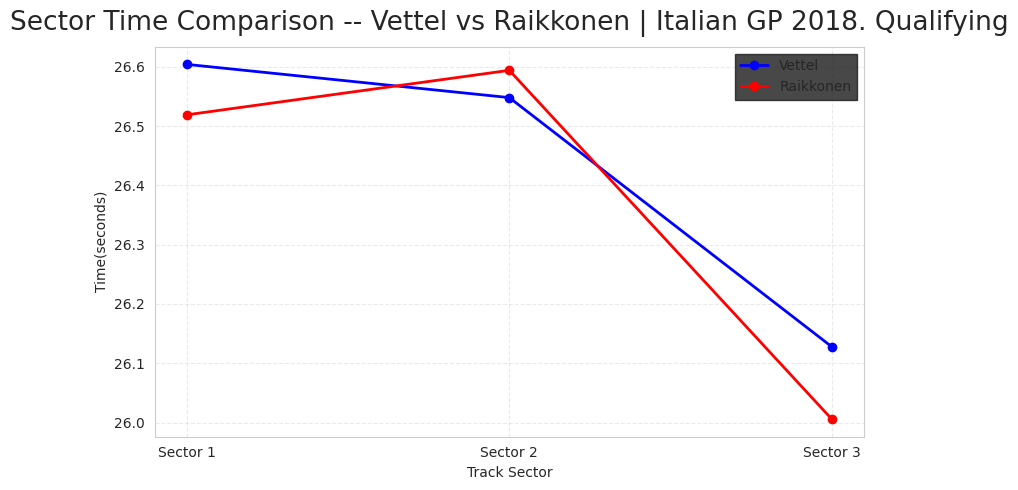

In [ ]:
# plot #6
# sector analysis
import os



# extract sector times
# vettel
vettel_sectors = [
    vettel_fastest["Sector1Time"].total_seconds(),
    vettel_fastest["Sector2Time"].total_seconds(),
    vettel_fastest["Sector3Time"].total_seconds()
]
# raikkonen
raikkonen_sectors = [
    raikkonen_fastest["Sector1Time"].total_seconds(),
    raikkonen_fastest["Sector2Time"].total_seconds(),
    raikkonen_fastest["Sector3Time"].total_seconds()
]

# sector labels
sectors = ["Sector 1", "Sector 2", "Sector 3"]
# plot
plt.figure(figsize=(8, 5))

plt.plot(sectors, vettel_sectors,
         marker="o",
         color="blue",
         linewidth=2,
         label="Vettel")
plt.plot(sectors, raikkonen_sectors,
         marker="o",
         color="red",
         linewidth=2,
         label="Raikkonen")

# labels
plt.ylabel("Time(seconds)")
plt.xlabel("Track Sector")

plt.title("Sector Time Comparison -- Vettel vs Raikkonen | Italian GP 2018. Qualifying")

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()

# save
plt.savefig(os.path.join(plots_folder, "sector analysis.png"), dpi=300)

plt.tight_layout()
plt.show()

**Sector Time**

This chart compares the total time spent in each of the three sectors.

Vettel was faster in Sector 1(heavy breaking and engine power), but Raikkonen dominated Sector 3.Raikkonen's car setup was better optimized for high-speed corners.

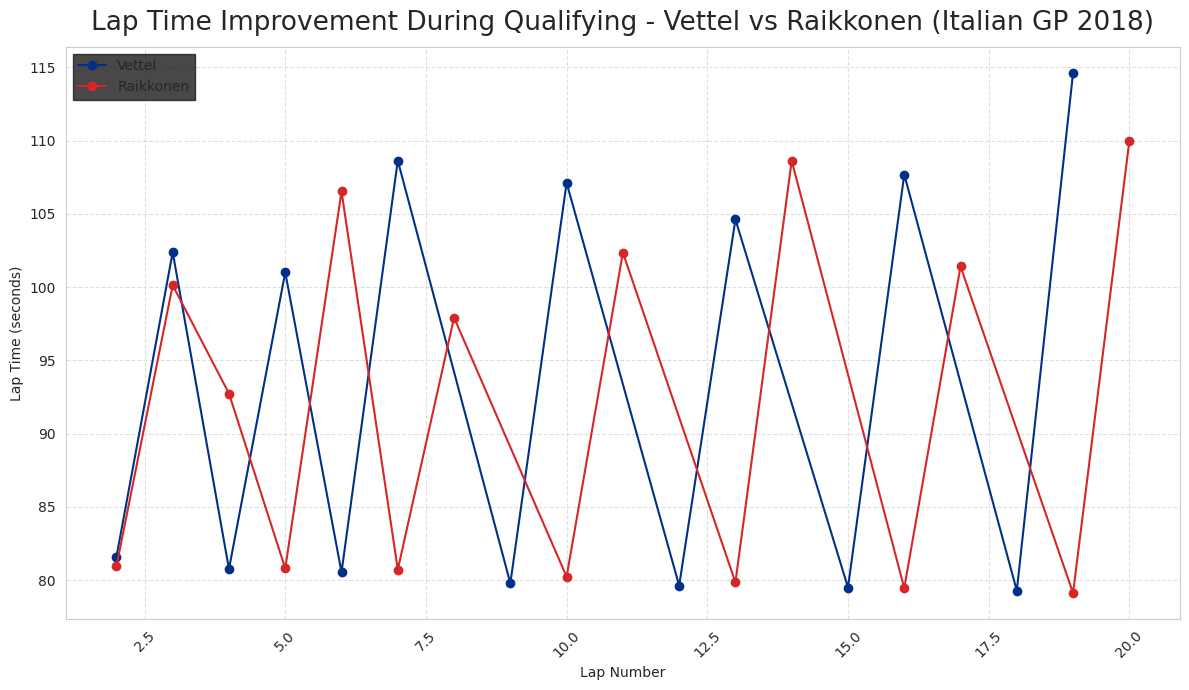

In [ ]:
import matplotlib.pyplot as plt

# Filter for valid laps with actual lap times
vettel_valid_laps = vettel_laps[vettel_laps['LapTime'].notna()].copy()
raikkonen_valid_laps = raikkonen_laps[raikkonen_laps['LapTime'].notna()].copy()

# Convert LapTime to total seconds for plotting
vettel_valid_laps['LapTimeSeconds'] = vettel_valid_laps['LapTime'].dt.total_seconds()
raikkonen_valid_laps['LapTimeSeconds'] = raikkonen_valid_laps['LapTime'].dt.total_seconds()

# Create the plot
plt.figure(figsize=(12, 7))

# Plot Vettel's lap times
plt.plot(
    vettel_valid_laps['LapNumber'],
    vettel_valid_laps['LapTimeSeconds'],
    marker='o',
    linestyle='-',
    color=driver_colors["Vettel"],
    label='Vettel'
)

# Plot Raikkonen's lap times
plt.plot(
    raikkonen_valid_laps['LapNumber'],
    raikkonen_valid_laps['LapTimeSeconds'],
    marker='o',
    linestyle='-',
    color=driver_colors["Raikkonen"],
    label='Raikkonen'
)

# Add labels and title
plt.xlabel('Lap Number')
plt.ylabel('Lap Time (seconds)')
plt.title('Lap Time Improvement During Qualifying - Vettel vs Raikkonen (Italian GP 2018)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

# Save the plot
plt.savefig(os.path.join(plots_folder, 'lap_improvement.png'), dpi=300)
plt.show()


**Lap Time Improvement**

This plot tracks how lap times decreased as the session progressed due to track evolution and fuel load reduction,

Both drivers consistently found more grip as the truck evolved.The peak performance was delivered under maximum pressure in the final run of Q3, extracting the absolute limit of SF71H.

## SQL

In [ ]:
import sqlite3
import pandas as pd

# create local SQLite database
conn = sqlite3.connect("f1_analysis.db")

# Convert timedelta columns to total seconds before saving to SQL
laps_copy = laps.copy()
for col in ["LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]:
    if col in laps_copy.columns:
        # Convert only non-NaT values to total_seconds, otherwise keep as NaN
        laps_copy[col] = laps_copy[col].apply(lambda x: x.total_seconds() if pd.notna(x) else None)

# save pandas dataframes to the database
laps_copy.to_sql("laps", conn,
if_exists="replace", index=False)

# queries
# fastest lap per driver
query_fastest  = """
SELECT Driver, MIN(LapTime) AS FastestLap
FROM laps
WHERE Driver IN ("VET", "RAI")
GROUP BY Driver
ORDER BY FastestLap ASC;
"""

fastest_lap_df = pd.read_sql_query(query_fastest, conn)
# Now, FastestLap is a float representing seconds, so no need for .astype(str) yet if we want to treat it as a number
print("Fastest Lap Data:")
print(fastest_lap_df)

# average sector times per driver
query_avg_sectors = """
SELECT Driver,
       AVG(Sector1Time) AS AvgSector1,
       AVG(Sector2Time) AS AvgSector2,
       AVG(Sector3Time) AS AvgSector3
FROM laps
WHERE Driver IN ("VET", "RAI")
GROUP BY Driver;
"""
result_avg_sectors = pd.read_sql_query(query_avg_sectors, conn)
print("\nAverage Sector Times (seconds):")
print(result_avg_sectors)

# number of laps per driver
query_num_laps = """
SELECT Driver, COUNT(*) AS NumLaps
FROM laps
GROUP BY Driver;
"""

result_num_laps = pd.read_sql_query(query_num_laps, conn)
print("\nNumber of Laps Per Driver:")
print(result_num_laps)

conn.close()

Fastest Lap Data:
  Driver  FastestLap
0    RAI      79.119
1    VET      79.280

Average Sector Times (seconds):
  Driver  AvgSector1  AvgSector2  AvgSector3
0    RAI   29.529933   31.191300   31.245850
1    VET   30.720571   30.615526   31.519316

Number of Laps Per Driver:
   Driver  NumLaps
0     ALO       14
1     BOT       18
2     ERI       10
3     GAS       24
4     GRO       21
5     HAM       19
6     HAR       12
7     HUL       12
8     LEC       10
9     MAG       12
10    OCO       17
11    PER        5
12    RAI       20
13    RIC        3
14    SAI       17
15    SIR       13
16    STR       14
17    VAN        9
18    VER       15
19    VET       19


/tmp/ipykernel_709/6836367.py:15: UserWarning: the 'timedelta' type is not supported, and will be written as integer values (ns frequency) to the database.
  laps_copy.to_sql("laps", conn,


**Average Sector Times & Number of Laps per Driver**

* By using SQL to break down the lap into three sectors, we can see where mechanical and aerodynamic advantages for each driver are.

Vettel maintains competitive in Sector 1(high speed braking zones), Raikkonen's average time in Sector 3 is superior, indicating a more sufficient aerodynamic setup for the technical corners.

* This query counts the total volume of data points(laps)processed for each driver on the grid.

Using the COUNT function we can see the workload distribution.Vettel and Raikkonen completed 19 and 20 laps.



In [ ]:
print("Fastest Lap Data (Table):")
display(fastest_lap_df)

print("\nAverage Sector Times (Table):")
display(result_avg_sectors)

print("\nNumber of Laps Per Driver (Table):")
display(result_num_laps)

Fastest Lap Data (Table):


,Driver,FastestLap
0,RAI,79.119
1,VET,79.280



Average Sector Times (Table):


,Driver,AvgSector1,AvgSector2,AvgSector3
0,RAI,29.529933,31.191300,31.245850
1,VET,30.720571,30.615526,31.519316



Number of Laps Per Driver (Table):


,Driver,NumLaps
0,ALO,14
1,BOT,18
2,ERI,10
3,GAS,24
4,GRO,21
5,HAM,19
6,HAR,12
7,HUL,12
8,LEC,10
9,MAG,12


In [ ]:
import sqlite3
import pandas as pd

# Make copies to avoid modifying the original DataFrames if they are used elsewhere
vettel_tel_db = vettel_tel.copy()
raikkonen_tel_db = raikkonen_tel.copy()

# Convert timedelta columns to total seconds for SQLite compatibility
for col in ["Time", "SessionTime"]:
    if col in vettel_tel_db.columns:
        vettel_tel_db[col] = vettel_tel_db[col].dt.total_seconds()
    if col in raikkonen_tel_db.columns:
        raikkonen_tel_db[col] = raikkonen_tel_db[col].dt.total_seconds()

# Connect to the SQLite database
conn = sqlite3.connect("f1_analysis.db")

# Save vettel_tel_db to a new table named vettel_telemetry
vettel_tel_db.to_sql("vettel_telemetry", conn, if_exists="replace", index=False)
print("Vettel telemetry data saved to 'vettel_telemetry' table.")

# Save raikkonen_tel_db to a new table named raikkonen_telemetry
raikkonen_tel_db.to_sql("raikkonen_telemetry", conn, if_exists="replace", index=False)
print("Raikkonen telemetry data saved to 'raikkonen_telemetry' table.")

# Close the database connection
conn.close()
print("Database connection closed.")

Vettel telemetry data saved to 'vettel_telemetry' table.
Raikkonen telemetry data saved to 'raikkonen_telemetry' table.
Database connection closed.


In [ ]:
import sqlite3
import pandas as pd

# Connect to the SQLite database
conn = sqlite3.connect("f1_analysis.db")

# Query for Vettel's average speed
query_vettel_avg_speed = "SELECT AVG(Speed) FROM vettel_telemetry;"
vettel_avg_speed = pd.read_sql_query(query_vettel_avg_speed, conn).iloc[0, 0]

# Query for Raikkonen's average speed
query_raikkonen_avg_speed = "SELECT AVG(Speed) FROM raikkonen_telemetry;"
raikkonen_avg_speed = pd.read_sql_query(query_raikkonen_avg_speed, conn).iloc[0, 0]

# Print the results
print(f"Vettel's Average Speed (Fastest Lap): {vettel_avg_speed:.2f} km/h")
print(f"Raikkonen's Average Speed (Fastest Lap): {raikkonen_avg_speed:.2f} km/h")

# Close the database connection
conn.close()


Vettel's Average Speed (Fastest Lap): 263.37 km/h
Raikkonen's Average Speed (Fastest Lap): 263.52 km/h


In [ ]:
import sqlite3
import pandas as pd

# Connect to the SQLite database
conn = sqlite3.connect("f1_analysis.db")

# SQL query to calculate average lap times per stint for Vettel and Raikkonen
query_avg_stint_times = """
SELECT Driver,
       Stint,
       AVG(LapTime) AS AverageLapTime
FROM laps
WHERE Driver IN ("VET", "RAI")
GROUP BY Driver, Stint
ORDER BY Driver, Stint;
"""

# Execute the query and store the result in a DataFrame
result_avg_stint_times = pd.read_sql_query(query_avg_stint_times, conn)

# Print the resulting DataFrame
print("\nAverage Lap Times Per Stint:")
print(result_avg_stint_times)

# Close the database connection
conn.close()


Average Lap Times Per Stint:
   Driver  Stint  AverageLapTime
0     RAI    NaN             NaN
1     RAI    1.0       91.393143
2     RAI    2.0       91.294000
3     RAI    3.0       94.229000
4     RAI    4.0       90.431000
5     RAI    5.0       94.547500
6     VET    NaN             NaN
7     VET    1.0       92.481667
8     VET    2.0       93.446500
9     VET    3.0       92.120500
10    VET    4.0       93.587000
11    VET    5.0       96.954000


**Average Lap Time per Stint**

This query calculates the lap time per driver during different phases(stints) of the session.This helps in understanding how performance fluctuates as track conditions improve.

The data shows high consistency for both drivers.Track evolution progressed, the lap times steadily dropped, which means that both drivers were finding more grip as the session reached its climax.

### Summary

**Overview**

This project provides technical and strategic comparison of Sebastian Vettel and Kimi Raikkonen during the 2018 Italian Grand Prix qualifying session.
By integrating Python(FastF1, Pandas, Matplotlib) and SQL(SQLite), I analyzed telemetry data and session-wide performance metrics to realize where the position was decided.


**Tech**

* **Data Engineering**: Extracted ans syncronized telemetry data(Speed, Throttle, Brake) across distance to ensure accurate comparison of the fastest laps.

* **SQL**: Developed a database to aggregate average sector times and stint consistency.

* **Visualization**: Created plots like Live Delta Time, Throttle Traces, Speed to visualize the invisible margins.


**Key Insights**

1.**The Deciding Factor**:

 While Vettel was superior in heavy breakung zones(Sector 1), the analysis proves that ***Raikkonen's higher minimum cornering speed*** in the Lesmos and a cleaner exit from the Parabolica(Sector 3) secured his position.


2.**Driving Styles**:

Telemetry reveals Vettel's aggressive input style versus Raikkonen's smoother, more progressive throttle application, was one of key factors in utilizing the track evolution during Q3.

3.**Data Integrity**:

SQL averages confirmed that both drivers were operating at peak efficiency, with the final gap of 0.1s being one of the smallest margins of the season, which proves the identical performance but different tactical approach.



***Conclusion***

This analysis demonstrates the ability to transform complex, high velocity sports data into insights.Full workflow: from raw data extraction to SQL to visualizations.